# Análise completa dos treinamentos do TCC

## tl;dr

Este notebook audita as 36 runs canônicas, reconcilia métricas de treino e teste, consolida uso de hardware e tempo, e compara os quatro modos de balanceamento dentro de cada dataset. As conclusões são preenchidas a partir das células executadas abaixo.

## Context & Methods

### Key Assumptions

- As runs canônicas de MNIST a CIFAR-100 Coarse vêm do perfil otimizado original.
- SVHN, GTSRB e FER2013 vêm da fila retomada em `E:`.
- Tentativas antigas/interrompidas e smoke tests não entram na análise.
- Comparações de balanceamento são feitas principalmente dentro do mesmo dataset; cada condição possui apenas a seed 42.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WINDOWS_PROJECT = Path(r'C:\source\repos\teste-modelos-tcc')
WSL_PROJECT = Path('/mnt/c/source/repos/teste-modelos-tcc')
PROJECT = WINDOWS_PROJECT if WINDOWS_PROJECT.exists() else WSL_PROJECT
WINDOWS_REMAINING = Path(r'E:\tcc-benchmark\outputs\remaining-ram-capped')
WSL_REMAINING = Path('/mnt/e/tcc-benchmark/outputs/remaining-ram-capped')
PRIMARY = PROJECT / 'outputs/full-100-epochs-batch512-wsl-optimized'
REMAINING = WINDOWS_REMAINING if WINDOWS_REMAINING.exists() else WSL_REMAINING
OUTPUT = PROJECT / 'outputs/training-analysis-2026-08-02'
sys.path.insert(0, str(PROJECT / 'scripts'))
from analyze_completed_benchmarks import build_analysis

analysis = build_analysis(PRIMARY, REMAINING, OUTPUT)
runs = analysis['runs'].copy()
epochs = analysis['epochs'].copy()
overview = analysis['overview']
overview

{'generated_at': '2026-08-09T23:24:25.502993+00:00',
 'canonical_runs': 36,
 'completed_runs': 36,
 'datasets': 9,
 'balance_modes': 4,
 'epochs_recorded': 2486,
 'training_seconds': 319893.07342043624,
 'training_hours': 88.85918706123229,
 'evaluation_seconds': 513.2022562790162,
 'examples_processed': 387531297.0,
 'quality_checks': 396,
 'failed_quality_checks': 1,
 'critical_or_high_failed_checks': 0,
 'all_datasets_within_dataset_comparable': True,
 'sample_weighted_gpu_util_mean_percent': 25.002577661251124,
 'sample_weighted_ram_mean_percent': 40.7445213651294,
 'peak_gpu_memory_gib': 7.638492584228516,
 'peak_ram_percent': 58.9,
 'peak_process_rss_gib': 9.144363403320312,
 'max_gpu_temperature_c': 61.0,
 'best_overall_run_id': 'gtsrb__zscore__oversample__seed-42',
 'best_overall_test_macro_f1': 0.9967489311523817,
 'single_seed_limitation': True,
 'canonical_primary_root': 'C:\\source\\repos\\teste-modelos-tcc\\outputs\\full-100-epochs-batch512-wsl-optimized',
 'canonical_rema

## Data

### 1. Validate Inputs

In [2]:
quality = analysis['checks']
failed = quality.loc[~quality['passed']]
print(f"Canonical runs: {len(runs)}; completed: {(runs.status == 'completed').sum()}")
print(f"Quality checks: {len(quality)}; failures: {len(failed)}")
analysis['comparability']

Canonical runs: 36; completed: 36
Quality checks: 396; failures: 1


,dataset,distinct_split_fingerprints,distinct_source_samples,distinct_batch_sizes,distinct_tensorflow_versions,distinct_shuffle_caps,within_dataset_comparable
0,cifar10,1,1,1,1,1,True
1,cifar100_coarse,1,1,1,1,1,True
2,emnist_balanced,1,1,1,1,1,True
3,fashion_mnist,1,1,1,1,1,True
4,fer2013,1,1,1,1,1,True
5,gtsrb,1,1,1,1,1,True
6,kmnist,1,1,1,1,1,True
7,mnist,1,1,1,1,1,True
8,svhn,1,1,1,1,1,True


## Results

### 2. Test Performance

In [3]:
display_cols = ['dataset','balance_mode','test_accuracy','test_balanced_accuracy','test_macro_f1',
                'best_epoch','epochs_completed','training_hours']
runs[display_cols].sort_values(['dataset','test_macro_f1'], ascending=[True,False]).round(4)

,dataset,balance_mode,test_accuracy,test_balanced_accuracy,test_macro_f1,best_epoch,epochs_completed,training_hours
17,cifar10,undersample,0.7457,0.7457,0.7441,75,85,1.7349
16,cifar10,all_raw,0.7436,0.7436,0.7420,56,66,1.4133
19,cifar10,class_weight,0.7436,0.7436,0.7420,56,66,1.3838
18,cifar10,oversample,0.7309,0.7309,0.7294,81,91,1.9309
22,cifar100_coarse,oversample,0.5276,0.5276,0.5258,75,85,1.7868
20,cifar100_coarse,all_raw,0.5146,0.5146,0.5129,62,72,1.5244
23,cifar100_coarse,class_weight,0.5146,0.5146,0.5129,62,72,1.5101
21,cifar100_coarse,undersample,0.5040,0.5040,0.5009,86,96,2.0298
13,emnist_balanced,undersample,0.8822,0.8822,0.8806,100,100,3.2393
12,emnist_balanced,all_raw,0.8796,0.8796,0.8777,85,95,3.2191


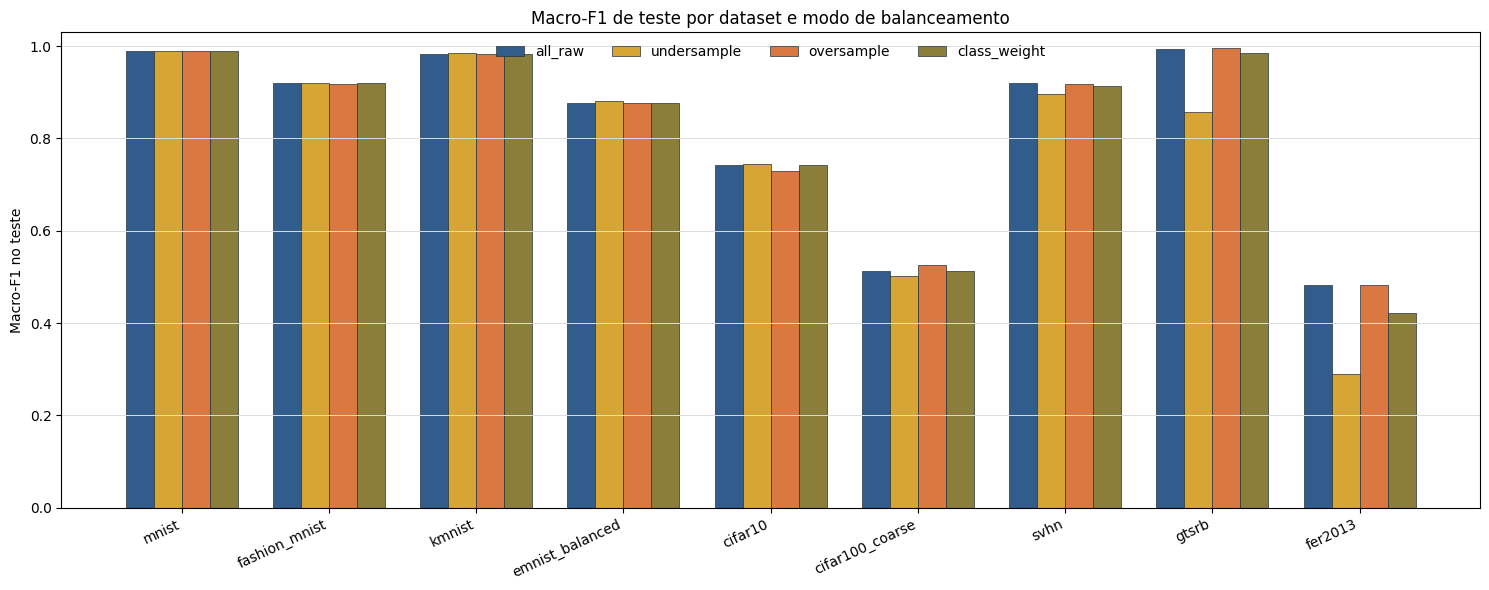

In [4]:
dataset_order = list(dict.fromkeys(runs['dataset']))
mode_order = ['all_raw','undersample','oversample','class_weight']
palette = {'all_raw':'#315C8C','undersample':'#D6A534','oversample':'#D97941','class_weight':'#8B7D3A'}
x = np.arange(len(dataset_order)); width = 0.19
fig, ax = plt.subplots(figsize=(15,6))
for index, mode in enumerate(mode_order):
    values = runs.set_index(['dataset','balance_mode']).loc[[(d,mode) for d in dataset_order], 'test_macro_f1'].to_numpy()
    ax.bar(x + (index-1.5)*width, values, width, label=mode, color=palette[mode], edgecolor='#263238', linewidth=.5)
ax.set_xticks(x, dataset_order, rotation=25, ha='right')
ax.set_ylabel('Macro-F1 no teste')
ax.set_title('Macro-F1 de teste por dataset e modo de balanceamento')
ax.set_ylim(0,1.03); ax.grid(axis='y', color='#D9DEE3', linewidth=.7); ax.legend(ncol=4, frameon=False)
fig.tight_layout(); plt.show()

### 3. Incremental Effect of Balancing

In [5]:
analysis['balance_summary'].round(5)

,balance_mode,mean_test_macro_f1,median_test_macro_f1,mean_delta_macro_f1_vs_all_raw,median_delta_macro_f1_vs_all_raw,dataset_wins,mean_training_hours,total_training_hours,mean_gpu_util_percent,mean_ram_percent
0,all_raw,0.82464,0.92010,0.00000,0.00000,2,2.49601,22.46407,27.56380,33.85497
2,oversample,0.82455,0.91851,-0.00009,-0.00028,3,2.87196,25.84762,27.65141,36.29387
1,class_weight,0.81646,0.91467,-0.00819,0.00000,2,2.73816,24.64344,27.98527,36.07656
3,undersample,0.78469,0.88057,-0.03995,-0.00110,3,1.76712,15.90406,28.53129,34.06474


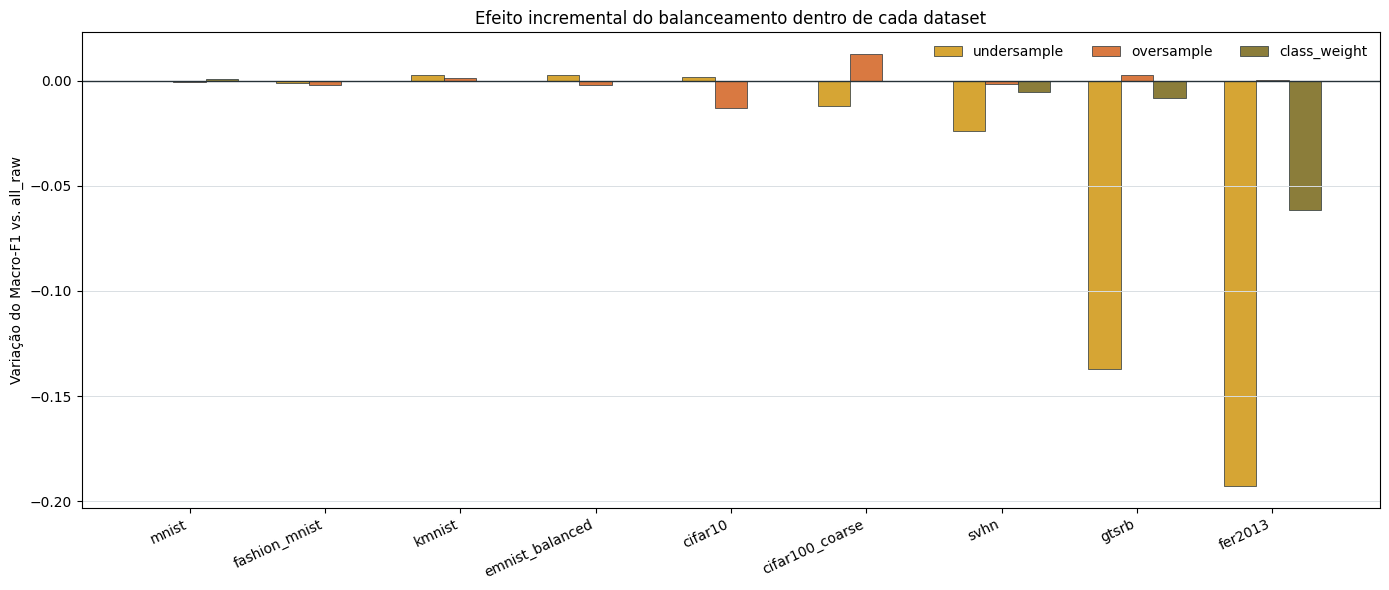

In [6]:
delta = runs.loc[runs.balance_mode != 'all_raw'].copy()
fig, ax = plt.subplots(figsize=(14,6))
for index, mode in enumerate(['undersample','oversample','class_weight']):
    values = delta.set_index(['dataset','balance_mode']).loc[[(d,mode) for d in dataset_order], 'delta_macro_f1_vs_all_raw'].to_numpy()
    ax.bar(x + (index-1)*0.24, values, .24, label=mode, color=palette[mode], edgecolor='#263238', linewidth=.5)
ax.axhline(0, color='#263238', linewidth=1)
ax.set_xticks(x, dataset_order, rotation=25, ha='right')
ax.set_ylabel('Variação do Macro-F1 vs. all_raw')
ax.set_title('Efeito incremental do balanceamento dentro de cada dataset')
ax.grid(axis='y', color='#D9DEE3', linewidth=.7); ax.legend(ncol=3, frameon=False)
fig.tight_layout(); plt.show()

### 4. Training Time and Hardware

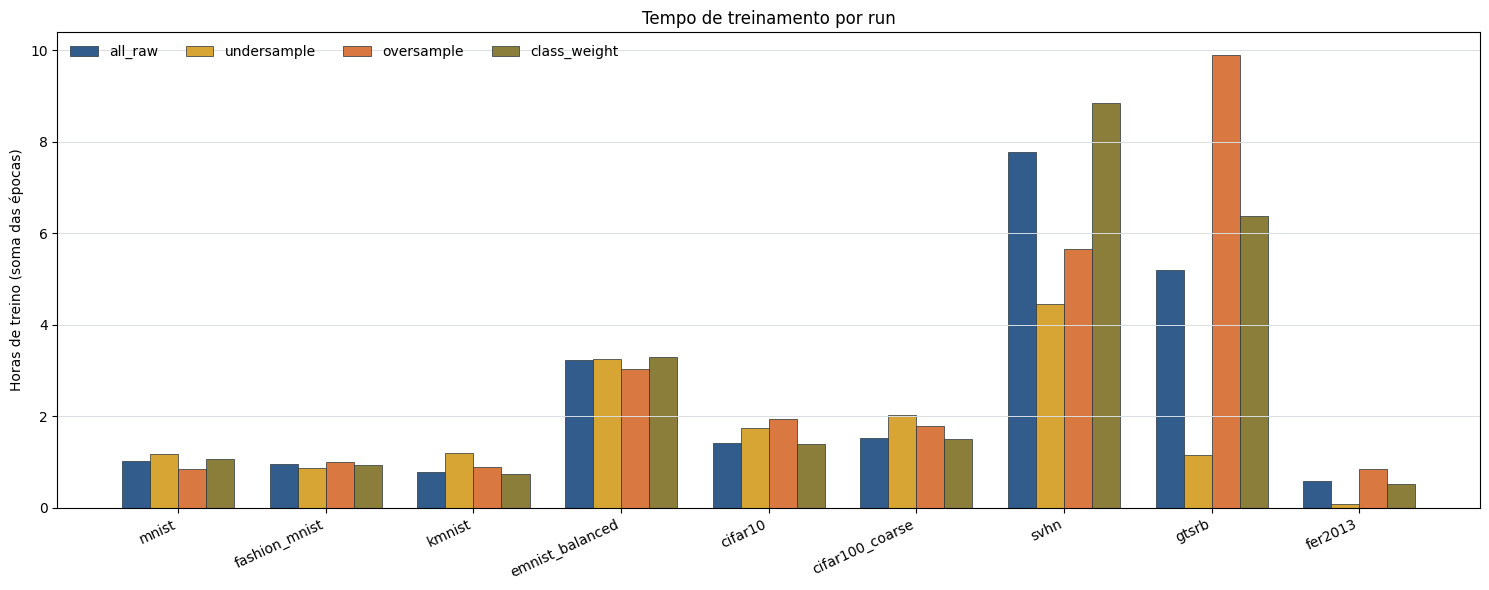

In [7]:
fig, ax = plt.subplots(figsize=(15,6))
for index, mode in enumerate(mode_order):
    values = runs.set_index(['dataset','balance_mode']).loc[[(d,mode) for d in dataset_order], 'training_hours'].to_numpy()
    ax.bar(x + (index-1.5)*width, values, width, label=mode, color=palette[mode], edgecolor='#263238', linewidth=.5)
ax.set_xticks(x, dataset_order, rotation=25, ha='right')
ax.set_ylabel('Horas de treino (soma das épocas)')
ax.set_title('Tempo de treinamento por run')
ax.grid(axis='y', color='#D9DEE3', linewidth=.7); ax.legend(ncol=4, frameon=False)
fig.tight_layout(); plt.show()

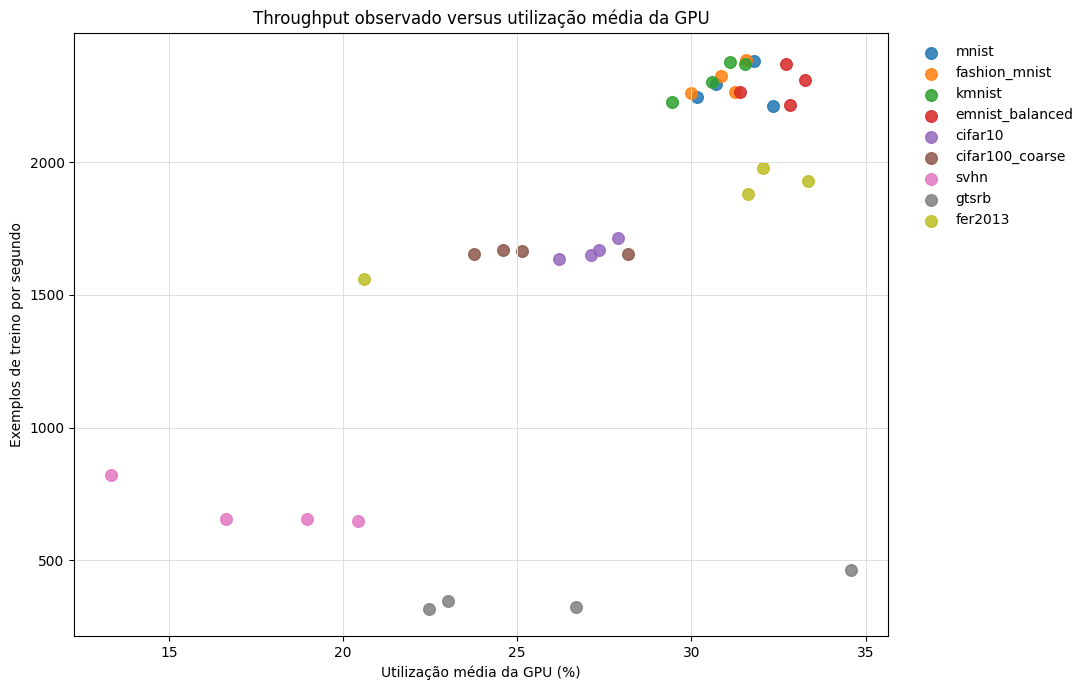

In [8]:
fig, ax = plt.subplots(figsize=(11,7))
for dataset, group in runs.groupby('dataset', sort=False):
    ax.scatter(group['gpu_util_mean_percent'], group['weighted_train_examples_per_second'], s=70, label=dataset, alpha=.85)
ax.set_xlabel('Utilização média da GPU (%)')
ax.set_ylabel('Exemplos de treino por segundo')
ax.set_title('Throughput observado versus utilização média da GPU')
ax.grid(color='#D9DEE3', linewidth=.7); ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
fig.tight_layout(); plt.show()

### 5. FER2013 Warning Check

In [9]:
fer = runs.query("dataset == 'fer2013' and balance_mode == 'class_weight'").iloc[0]
fer_epochs = epochs.query("dataset == 'fer2013' and balance_mode == 'class_weight'")
print(f"Best epoch: {fer.best_epoch}; completed: {fer.epochs_completed}; after best: {fer.epochs_after_best}")
print(f"Early stopping consistent: {fer.early_stop_consistent}; final epoch batches were fully recorded.")
fer_epochs[['epoch','val_macro_f1','learning_rate','epoch_seconds','train_examples']].tail(12)

Best epoch: 36; completed: 46; after best: 10
Early stopping consistent: True; final epoch batches were fully recorded.


,epoch,val_macro_f1,learning_rate,epoch_seconds,train_examples
2474,35,0.400798,0.000090,39.143840,75363.0
2475,36,0.416390,0.000090,39.723721,75363.0
2476,37,0.414495,0.000090,40.007059,75363.0
2477,38,0.406221,0.000090,39.633381,75363.0
2478,39,0.404715,0.000090,39.618219,75363.0
2479,40,0.401535,0.000090,39.323252,75363.0
2480,41,0.408462,0.000027,38.911339,75363.0
2481,42,0.415513,0.000027,39.609680,75363.0
2482,43,0.415185,0.000027,39.470078,75363.0
2483,44,0.410364,0.000027,39.691771,75363.0


## Takeaways

### 6. Reproducible Summary

In [10]:
best = runs.loc[runs.groupby('dataset')['test_macro_f1'].idxmax(), ['dataset','balance_mode','test_macro_f1']]
print('Best balance mode by dataset:')
display(best.sort_values('dataset').round(4))
print(f"Total training time: {overview['training_hours']:.2f} h across {overview['epochs_recorded']} epochs.")
print(f"Peak RAM: {overview['peak_ram_percent']:.1f}%; peak GPU memory: {overview['peak_gpu_memory_gib']:.2f} GiB.")
print('Primary limitation: one seed per condition, so differences are descriptive rather than inferential.')

Best balance mode by dataset:


,dataset,balance_mode,test_macro_f1
17,cifar10,undersample,0.7441
22,cifar100_coarse,oversample,0.5258
13,emnist_balanced,undersample,0.8806
4,fashion_mnist,all_raw,0.9209
34,fer2013,oversample,0.4828
30,gtsrb,oversample,0.9967
9,kmnist,undersample,0.9854
3,mnist,class_weight,0.9902
24,svhn,all_raw,0.9201


Total training time: 88.86 h across 2486 epochs.
Peak RAM: 58.9%; peak GPU memory: 7.64 GiB.
Primary limitation: one seed per condition, so differences are descriptive rather than inferential.
